<a href="https://colab.research.google.com/github/Zhansaya0000/Andrew-Ng-Coursera-Machine-learning-in-Python/blob/main/scorecard_zhansaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/Сводные данные_fixed2.xlsx'

Построение рейтинговой скоринговой модели на основе логистической регрессии




In [ ]:
df = pd.read_excel(file_path)

In [ ]:
df.shape

(227, 54)

In [ ]:
df.columns

Index(['%п.п', 'Название проекта ', 'Дата заявки', 'Дата ПСД', 'Застройщик',
       'Уполномоченная Компания', 'Город реализации проекта',
       'Проектная стоиомсть строительства, тыс.тг.',
       'Площадь строительства по заявленному проекту тыс.кв.м.',
       'Срок реализации мес.', 'Start Date',
       'Незавершенное строительство, тыс.тг.', 'Денежные средства, тыс.тг.',
       'Цена за кв.м. квартир по проекту, тыс.тг.',
       'Цена за кв.м. квартир на рынке, тыс.тг.', 'Квартиры площадь тыс.кв.м',
       'Квартиры цена тыс.тг', 'Общая стоимость квартиры , тыс.тг',
       'Коммерческие помещения площадь тыс.кв.м',
       'Коммерческие помещения цена тыс.тг',
       'Коммерческие помещения стоимость ', 'Паркинги ед. площадь тыс.кв.м',
       'Паркинги ед. цена тыс.тг', 'Паркинги ед. стоимость ',
       'Выручка с продаж, тыс.тг.', 'Рентабельность',
       'Чувствительность к удорожанию',
       'Остаток работ по текущим проектам, тыс.тг.',
       'Коэффициент рентабельности деятел

## Подготовка данных

На данном этапе проводится первичный анализ и подготовка данных для построения модели.

Включает:
- проверку типов данных,
- обработку пропусков,
- выделение целевой переменной (Target),
- анализ распределений признаков.

Целевая переменная:
- 1 — дефолт (плохой объект),
- 0 — недефолт (хороший объект).

Корректная подготовка данных необходима для обеспечения устойчивости и интерпретируемости модели.


In [ ]:
df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')
df['end_month'] = df['End Date'].dt.month
def get_season(month):
    if pd.isna(month):
        return 'MISSING'
    elif month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'autumn'
df['end_season'] = df['end_month'].apply(get_season)
df = df.drop(columns=['End Date', 'end_month'])

/tmp/ipython-input-1637877832.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')


In [ ]:
cols_to_drop = ['Название проекта ', 'Unnamed: 49', 'Unnamed: 50', 'Комментарии ', 'plan_term', 'life_e', '%п.п','Неисполнение обязательств по ДПГ (Наличие уведомлений о ненадлежащем исполнении обязательств по договорам о предоставлении гарантии, заключенными с Застройщиком и/или Уполномоченной компанией, за 2 последних календарных года к дате подачи заявки)', '%п.п', 'Название проекта ', 'Дата заявки', 'Дата ПСД', 'Застройщик',
       'Уполномоченная Компания', 'Start Date', 'Кредитная история за последние 3 года (наличие просрочки по платежам в прошлом)','Цена за кв.м. квартир по проекту, тыс.тг.',
                'Квартиры площадь тыс.кв.м', 'Квартиры цена тыс.тг','Общая стоимость квартиры , тыс.тг',
                'Коммерческие помещения стоимость','Паркинги ед. стоимость','Рентабельность', 'Коэффициент маневренности', ]

df.columns = df.columns.str.strip()
df = df.drop(columns=[c.strip() for c in cols_to_drop], errors='ignore')


print("Форма датасета после удаления колонок:", df.shape)
print("Остальные колонки:")
display(df.columns)


Форма датасета после удаления колонок: (227, 32)
Остальные колонки:


Index(['Город реализации проекта',
       'Проектная стоиомсть строительства, тыс.тг.',
       'Площадь строительства по заявленному проекту тыс.кв.м.',
       'Срок реализации мес.', 'Незавершенное строительство, тыс.тг.',
       'Денежные средства, тыс.тг.', 'Цена за кв.м. квартир на рынке, тыс.тг.',
       'Коммерческие помещения площадь тыс.кв.м',
       'Коммерческие помещения цена тыс.тг', 'Паркинги ед. площадь тыс.кв.м',
       'Паркинги ед. цена тыс.тг', 'Выручка с продаж, тыс.тг.',
       'Чувствительность к удорожанию',
       'Остаток работ по текущим проектам, тыс.тг.',
       'Коэффициент рентабельности деятельности',
       'Коэффициент рентабельности активов',
       'Коэффициент рентабельности собственного капитала',
       'Коэффициент текущей ликвидности',
       'Project Coverage Ratio (операционные потоки/расходы по ГПР за один год)',
       'Коэффициент автономии', 'Коэффициент финансового рычага',
       'Объем введенной в эксплуатацию площади жилья (квадратных ме

In [ ]:
cat_cols=['end_season','Город реализации проекта','Коммерческая привлекательность цены']

In [ ]:
num_cols = [col for col in df.columns if col not in cat_cols]
num_cols.remove('Target')


In [ ]:
for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace(' ', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
df[num_cols] = df[num_cols].fillna(0)


In [ ]:
df.shape

(227, 32)

In [ ]:
df.columns

Index(['Город реализации проекта',
       'Проектная стоиомсть строительства, тыс.тг.',
       'Площадь строительства по заявленному проекту тыс.кв.м.',
       'Срок реализации мес.', 'Незавершенное строительство, тыс.тг.',
       'Денежные средства, тыс.тг.', 'Цена за кв.м. квартир на рынке, тыс.тг.',
       'Коммерческие помещения площадь тыс.кв.м',
       'Коммерческие помещения цена тыс.тг', 'Паркинги ед. площадь тыс.кв.м',
       'Паркинги ед. цена тыс.тг', 'Выручка с продаж, тыс.тг.',
       'Чувствительность к удорожанию',
       'Остаток работ по текущим проектам, тыс.тг.',
       'Коэффициент рентабельности деятельности',
       'Коэффициент рентабельности активов',
       'Коэффициент рентабельности собственного капитала',
       'Коэффициент текущей ликвидности',
       'Project Coverage Ratio (операционные потоки/расходы по ГПР за один год)',
       'Коэффициент автономии', 'Коэффициент финансового рычага',
       'Объем введенной в эксплуатацию площади жилья (квадратных ме

In [ ]:
df.to_excel('/content/drive/MyDrive/clean_dataset.xlsx', index=False)


BINING

## Биннинг признаков

Биннинг процесс разбиения непрерывных признаков на интервалы (бины)

Цели биннинга:
- сглаживание шума и выбросов,
- выявление зависимости признака от вероятности дефолта,
- подготовка данных к WOE-преобразованию,
- обеспечение монотонности риска.

В работе используется оптимальный биннинг, который:
- учитывает целевую переменную,
- максимизирует различие между good и bad,
- повышает информационную ценность признака (IV),
- обеспечивает устойчивость модели


In [ ]:
num_cols = [c for c in df.columns if c not in cat_cols + ['Target']]


In [ ]:
X = df[num_cols + cat_cols]
y = df['Target']


In [ ]:
!pip install optbinning



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 22.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatib

In [ ]:
from optbinning import OptimalBinning
X_woe = pd.DataFrame(index=df.index)
binning_models = {}
iv_dict = {}

## WOE-преобразование (Weight of Evidence)

WOE (Weight of Evidence) — статистическая мера, отражающая силу влияния интервала признака на риск дефолта.

Формула расчёта:

WOE_i = ln((Good_i / Good_total) / (Bad_i / Bad_total))

Где:
- Good_i — количество недефолтных наблюдений в i-м интервале,
- Bad_i — количество дефолтных наблюдений в i-м интервале.

Преимущества WOE:
- делает зависимость признака от логита линейной,
- повышает устойчивость логистической регрессии,
- обеспечивает интерпретируемость коэффициентов модели.

После биннинга каждый признак заменяется его WOE-значениями.


In [ ]:

for col in num_cols:
    optb = OptimalBinning(
        name=col,
        dtype="numerical",
        solver="cp"
    )

    optb.fit(df[col], y)

    X_woe[col] = optb.transform(df[col], metric="woe")
    binning_models[col] = optb

    optb.binning_table.build()
    iv_dict[col] = optb.binning_table.iv



for cat_cols

In [ ]:
for col in cat_cols:
    optb = OptimalBinning(
        name=col,
        dtype="categorical",
        solver="cp"
    )

    optb.fit(df[col], y)

    X_woe[col] = optb.transform(df[col], metric="woe")
    binning_models[col] = optb

    optb.binning_table.build()
    iv_dict[col] = optb.binning_table.iv


## Information Value (IV)

Information Value (IV) используется для оценки прогностической силы признака.

Формула:

IV = Σ (Good_i − Bad_i) × WOE_i

IV используется для отбора признаков в модель.


In [ ]:
iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV'])
iv_df.sort_values('IV', ascending=False)


,IV
Город реализации проекта,1.229034
Коэффициент автономии,0.894640
"Цена за кв.м. квартир на рынке, тыс.тг.",0.693115
Площадь строительства по заявленному проекту тыс.кв.м.,0.463389
Коэффициент финансового рычага,0.393495
Срок реализации мес.,0.375807
"Проектная стоиомсть строительства, тыс.тг.",0.348057
"Количество введенных в эксплуатацию объектов, получивших гарантию Единого оператора, за весь срок",0.343551
Чувствительность к удорожанию,0.312219
Коэффициент рентабельности деятельности,0.306013


In [ ]:
from IPython.display import display, Markdown
for feature, optb in binning_models.items():
    print(f'\n==============================')
    print(f'FEATURE: {feature}')
    print(f'==============================')

    bt = optb.binning_table.build()
    display(bt)



FEATURE: Проектная стоиомсть строительства, тыс.тг.


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 530292.00)",100,0.440529,85,15,0.150000,0.59444,0.131644,0.016217
1,"[530292.00, 3140440.00)",51,0.224670,35,16,0.313725,-0.357402,0.031244,0.003885
2,"[3140440.00, 4154244.00)",18,0.079295,8,10,0.555556,-1.363305,0.184464,0.021423
3,"[4154244.00, 7781859.00)",32,0.140969,24,8,0.250000,-0.041549,0.000246,0.000031
4,"[7781859.00, inf)",26,0.114537,20,6,0.230769,0.063812,0.000459,0.000057
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,227,1.000000,172,55,0.242291,,0.348057,0.041614



FEATURE: Площадь строительства по заявленному проекту тыс.кв.м.


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 7.11)",23,0.101322,11,12,0.521739,-1.227173,0.189265,0.022277
1,"[7.11, 18.50)",89,0.392070,64,25,0.280899,-0.200154,0.016503,0.002059
2,"[18.50, 21.50)",22,0.096916,21,1,0.045455,1.904361,0.197884,0.021567
3,"[21.50, 26.86)",22,0.096916,19,3,0.136364,0.705665,0.039461,0.004833
4,"[26.86, inf)",71,0.312775,57,14,0.197183,0.263833,0.020276,0.002527
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,227,1.000000,172,55,0.242291,,0.463389,0.053263



FEATURE: Срок реализации мес.


...

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[autumn],61,0.268722,54,7,0.114754,0.902913,0.168556,0.020382
1,[winter],62,0.273128,46,16,0.258065,-0.084109,0.001974,0.000247
2,[summer],51,0.224670,36,15,0.294118,-0.264693,0.016788,0.002092
3,[spring],53,0.233480,36,17,0.320755,-0.389856,0.038903,0.004832
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,227,1.000000,172,55,0.242291,,0.226221,0.027553



FEATURE: Город реализации проекта


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[Актау, Алматинская область, Талгарский район,...",55,0.242291,49,6,0.109091,0.9599,0.168743,0.020319
1,[Астана],122,0.537445,99,23,0.188525,0.319464,0.050284,0.006259
2,[Шымкент],22,0.096916,16,6,0.272727,-0.159332,0.002560,0.000320
3,"[Акмолинская область, город Косшы, мкр-н Лесна...",13,0.057269,7,6,0.461538,-0.986011,0.067436,0.008104
4,"[Усть-Каменогорск, ЗКО, р-н Бәйтерек, Мичуринс...",15,0.066079,1,14,0.933333,-3.779219,0.940011,0.076308
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,227,1.000000,172,55,0.242291,,1.229034,0.111309



FEATURE: Коммерческая привлекательность цены


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[около рынка],156,0.687225,123,33,0.211538,0.175516,0.020205,0.002522
1,[ниже рынка],31,0.136564,24,7,0.225806,0.091982,0.001128,0.000141
2,[выше рынка],40,0.176211,25,15,0.375000,-0.629336,0.080164,0.009858
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,227,1.000000,172,55,0.242291,,0.101496,0.012522


log reg

## Построение модели логистической регрессии

Логистическая регрессия используется для оценки вероятности дефолта (PD).

Модель имеет вид:

PD = 1 / (1 + e^(-z))

где:

z = β0 + β1·WOE1 + β2·WOE2 + ... + βn·WOEn

Модель обучается на WOE-преобразованных признаках.


In [ ]:

selected_features = [col for col, iv in iv_dict.items() if iv > 0.05]
print("Выбранные признаки:", selected_features)
X = X_woe[selected_features]
y = df['Target']


Выбранные признаки: ['Проектная стоиомсть строительства, тыс.тг.', 'Площадь строительства по заявленному проекту тыс.кв.м.', 'Срок реализации мес.', 'Незавершенное строительство, тыс.тг.', 'Денежные средства, тыс.тг.', 'Цена за кв.м. квартир на рынке, тыс.тг.', 'Коммерческие помещения площадь тыс.кв.м', 'Коммерческие помещения цена тыс.тг', 'Паркинги ед. цена тыс.тг', 'Выручка с продаж, тыс.тг.', 'Чувствительность к удорожанию', 'Остаток работ по текущим проектам, тыс.тг.', 'Коэффициент рентабельности деятельности', 'Коэффициент рентабельности активов', 'Коэффициент рентабельности собственного капитала', 'Коэффициент текущей ликвидности', 'Project Coverage Ratio (операционные потоки/расходы по ГПР за один год)', 'Коэффициент автономии', 'Коэффициент финансового рычага', 'Объем введенной в эксплуатацию площади жилья (квадратных метров) за 3 последних года (предлагается сравнение подтвержденного опыта с объемом по проекту)', 'Максимальное отставание от нормативного срока строительства, м

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## Оценка качества модели

Качество модели оценивается с использованием метрик:

### AUC ROC
Показывает способность модели различать дефолтные и недефолтные объекты

### Gini
Gini = 2 × AUC − 1

Чем выше значение Gini, тем лучше дискриминационная способность модели


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred = lr.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred)
gini = 2*auc - 1
print(f"AUC={auc:.3f}, Gini={gini:.3f}")


AUC=0.867, Gini=0.733


In [ ]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': lr.coef_[0]
}).sort_values(by='coef', ascending=False)

coef_df


,feature,coef
3,"Незавершенное строительство, тыс.тг.",0.748905
29,Коммерческая привлекательность цены,0.618963
7,Коммерческие помещения цена тыс.тг,0.535211
22,Максимальное количество продлений сроков по вв...,0.519958
16,Project Coverage Ratio (операционные потоки/ра...,0.045687
20,Максимальное отставание от нормативного срока ...,-0.021756
13,Коэффициент рентабельности активов,-0.042408
14,Коэффициент рентабельности собственного капитала,-0.122532
24,Доля собственного участия,-0.148477
12,Коэффициент рентабельности деятельности,-0.267742


In [ ]:
top_n = 8
coef_filtered = coef_df[coef_df['feature'].isin(selected_features)].copy()

coef_filtered['abs_coef'] = coef_filtered['coef'].abs()
significant_features = coef_filtered.sort_values(by='abs_coef', ascending=False).head(top_n)['feature'].tolist()

print("Выбрано фичей для скор-карты:", significant_features)


Выбрано фичей для скор-карты: ['Цена за кв.м. квартир на рынке, тыс.тг.', 'Площадь строительства по заявленному проекту тыс.кв.м.', 'Коэффициент финансового рычага', 'Коммерческие помещения площадь тыс.кв.м', 'Коэффициент автономии', 'Паркинги ед. цена тыс.тг', 'Город реализации проекта', 'Незавершенное строительство, тыс.тг.']


scorecard with points

In [ ]:
import numpy as np
import pandas as pd

PDO = 20
factor = PDO / np.log(2)

points_df = pd.DataFrame()

for feature in significant_features:
    optb = binning_models[feature]
    bt = optb.binning_table.build()

    bt['WoE'] = pd.to_numeric(bt['WoE'], errors='coerce')


    bt['Points'] = -bt['WoE'] * coef_df.loc[coef_df['feature']==feature, 'coef'].values[0] * factor
    bt['feature'] = feature


    points_df = pd.concat([points_df, bt[['feature','Bin','WoE','Points']]])

points_df['Points'] = points_df['Points'].round(0)

points_df.head(20)



,feature,Bin,WoE,Points
0,"Цена за кв.м. квартир на рынке, тыс.тг.","(-inf, 259.00)",-0.041549,-2.0
1,"Цена за кв.м. квартир на рынке, тыс.тг.","[259.00, 326.50)",0.199613,8.0
2,"Цена за кв.м. квартир на рынке, тыс.тг.","[326.50, 356.50)",2.573411,99.0
3,"Цена за кв.м. квартир на рынке, тыс.тг.","[356.50, 406.50)",-0.419615,-16.0
4,"Цена за кв.м. квартир на рынке, тыс.тг.","[406.50, inf)",-0.470004,-18.0
5,"Цена за кв.м. квартир на рынке, тыс.тг.",Special,0.000000,0.0
6,"Цена за кв.м. квартир на рынке, тыс.тг.",Missing,0.000000,0.0
Totals,"Цена за кв.м. квартир на рынке, тыс.тг.",,NaN,NaN
0,Площадь строительства по заявленному проекту т...,"(-inf, 7.11)",-1.227173,-45.0
1,Площадь строительства по заявленному проекту т...,"[7.11, 18.50)",-0.200154,-7.0


In [ ]:
points_df.head(60)

,feature,Bin,WoE,Points
0,"Цена за кв.м. квартир на рынке, тыс.тг.","(-inf, 259.00)",-0.041549,-2.0
1,"Цена за кв.м. квартир на рынке, тыс.тг.","[259.00, 326.50)",0.199613,8.0
2,"Цена за кв.м. квартир на рынке, тыс.тг.","[326.50, 356.50)",2.573411,99.0
3,"Цена за кв.м. квартир на рынке, тыс.тг.","[356.50, 406.50)",-0.419615,-16.0
4,"Цена за кв.м. квартир на рынке, тыс.тг.","[406.50, inf)",-0.470004,-18.0
5,"Цена за кв.м. квартир на рынке, тыс.тг.",Special,0.000000,0.0
6,"Цена за кв.м. квартир на рынке, тыс.тг.",Missing,0.000000,0.0
Totals,"Цена за кв.м. квартир на рынке, тыс.тг.",,NaN,NaN
0,Площадь строительства по заявленному проекту т...,"(-inf, 7.11)",-1.227173,-45.0
1,Площадь строительства по заявленному проекту т...,"[7.11, 18.50)",-0.200154,-7.0


In [ ]:
X_score['Target'] = df['Target']
X_score[['Score','Decision','Target']].head(20)

,Score,Decision,Target
0,60.0,Approve,0
1,58.0,Approve,0
2,46.0,Decline,0
3,52.0,Approve,0
4,78.0,Approve,0
5,75.0,Approve,0
6,54.0,Approve,0
7,58.0,Approve,0
8,67.0,Approve,0
9,42.0,Decline,1


In [ ]:

output_file = "/content/drive/MyDrive/scorecard_full.xlsx"
X_score['Target'] = df['Target']
X_score.to_excel(output_file, index=False)

print(f"Файл сохранён: {output_file}")


Файл сохранён: /content/drive/MyDrive/scorecard_full.xlsx


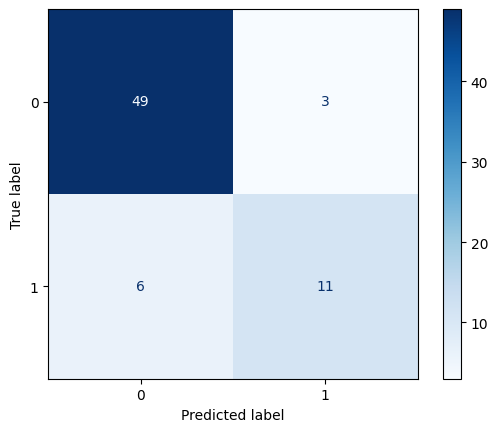

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot(cmap='Blues')


catboosting

In [ ]:
gini = 2*auc - 1
print( gini)

0.5746606334841629


0:	test: 0.7483032	best: 0.7483032 (0)	total: 47.6ms	remaining: 23.8s
100:	test: 0.7624434	best: 0.7873303 (53)	total: 89.6ms	remaining: 354ms
200:	test: 0.7466063	best: 0.7873303 (53)	total: 134ms	remaining: 199ms
300:	test: 0.7409502	best: 0.7873303 (53)	total: 174ms	remaining: 115ms
400:	test: 0.7341629	best: 0.7873303 (53)	total: 215ms	remaining: 53.2ms
499:	test: 0.7296380	best: 0.7873303 (53)	total: 259ms	remaining: 0us

bestTest = 0.7873303167
bestIteration = 53

Shrink model to first 54 iterations.
AUC CatBoost: 0.7873303167420814


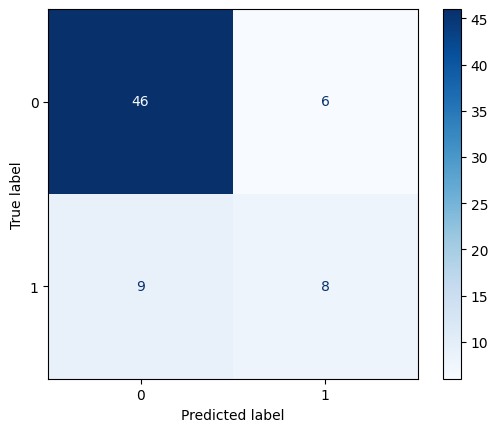

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

X = X_woe[significant_features]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
cb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=4,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cb.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=100)


y_pred_prob = cb.predict_proba(X_test)[:,1]
y_pred = cb.predict(X_test)


auc = roc_auc_score(y_test, y_pred_prob)
print("AUC CatBoost:", auc)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cb.classes_)
disp.plot(cmap='Blues')


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.2 MB/s eta 0:00:00


full features

0:	test: 0.5995475	best: 0.5995475 (0)	total: 4.76ms	remaining: 2.37s
100:	test: 0.8031674	best: 0.8088235 (60)	total: 251ms	remaining: 993ms
200:	test: 0.8133484	best: 0.8144796 (196)	total: 382ms	remaining: 568ms
300:	test: 0.8223982	best: 0.8223982 (295)	total: 591ms	remaining: 391ms
400:	test: 0.8257919	best: 0.8257919 (399)	total: 771ms	remaining: 190ms
499:	test: 0.8246606	best: 0.8269231 (478)	total: 982ms	remaining: 0us

bestTest = 0.8269230769
bestIteration = 478

Shrink model to first 479 iterations.
AUC CatBoost: 0.826923076923077


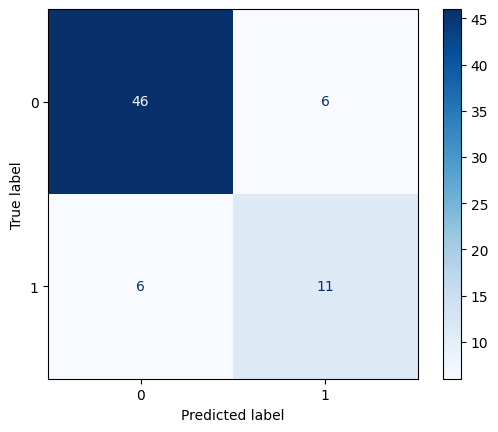

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# все признаки WOE
X = X_woe.copy()
y = df['Target']

# делим на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# создаём модель CatBoost
cb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=4,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

cb.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=100)

y_pred_prob = cb.predict_proba(X_test)[:,1]
y_pred = cb.predict(X_test)

auc = roc_auc_score(y_test, y_pred_prob)
print("AUC CatBoost:", auc)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cb.classes_)
disp.plot(cmap='Blues')


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_prob = cb.predict_proba(X_test)[:,1]


auc = roc_auc_score(y_test, y_pred_prob)


gini = 2 * auc - 1
print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")


AUC: 0.8269
Gini: 0.6538


In [ ]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = X_woe.copy()
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# RandomForest
rf = RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
gini_rf = 2 * auc_rf - 1

# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_prob_xgb = xgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
gini_xgb = 2 * auc_xgb - 1


print(f"RandomForest: AUC = {auc_rf:.4f}, Gini = {gini_rf:.4f}")
print(f"XGBoost: AUC = {auc_xgb:.4f}, Gini = {gini_xgb:.4f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:20:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomForest: AUC = 0.7907, Gini = 0.5814
XGBoost: AUC = 0.7590, Gini = 0.5181
